# **Fine-Grained Sentiment Analysis (3 classes) Yelp Reviews  - Comparison**

### Install Dependencies

In [1]:
!pip install -q transformers==4.41.2 peft==0.11.1 accelerate==0.31.0 datasets
!pip install -q psutil


[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: pip install --upgrade pip


### Imports

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time
import psutil
import torch
import gc

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    accuracy_score, precision_recall_fscore_support,
    confusion_matrix, ConfusionMatrixDisplay,
    classification_report
)
from sklearn.metrics.pairwise import cosine_similarity

from transformers import (
    AutoTokenizer, AutoModelForSequenceClassification,
    Trainer, TrainingArguments, EarlyStoppingCallback, AutoConfig
)
from peft import LoraConfig, TaskType, get_peft_model


# from google.colab import drive
# drive.mount('/content/drive', force_remount=True)

### Load and Explore Data

Total instances: 85000
Number of instances per sentiment:
Sentiment
0    36850
2    31278
1    16872
Name: count, dtype: int64


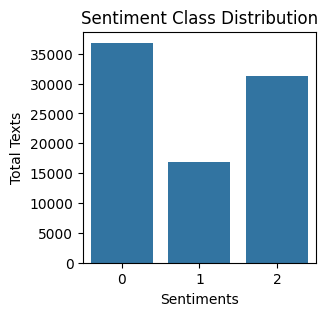

In [3]:
# file_path = "/content/drive/MyDrive/E-Commerce Reviews (5 Classes).csv"
# df = pd.read_csv(file_path, encoding='ISO-8859-1')
# df = df[['Text', 'Sentiment']].dropna()
# df.head()

file_path = "/home/arafatmdeasin/usman/project/dataset/Yelp Reviews.csv"
df = pd.read_csv(file_path, encoding='ISO-8859-1')[['Text', 'Sentiment']].dropna()

def convert_to_3_classes(sentiment):
    if sentiment in [1, 2]:
        return 0  # Negative
    elif sentiment == 3:
        return 1  # Neutral
    else:
        return 2  # Positive

df['Sentiment'] = df['Sentiment'].apply(convert_to_3_classes)

total_instances = len(df)
print(f"Total instances: {total_instances}")

sentiment_counts = df['Sentiment'].value_counts()
print("Number of instances per sentiment:")
print(sentiment_counts)

plt.figure(figsize=(3,3))
sns.countplot(x='Sentiment', data=df)
plt.title("Sentiment Class Distribution")
plt.xlabel("Sentiments")
plt.ylabel("Total Texts")
plt.grid(False)
plt.show()


### Preprocessing

In [4]:
total_instances = len(df)
print(f"Total instances: {total_instances}")

sentiment_counts = df['Sentiment'].value_counts()
print("Number of instances per sentiment:")
print(sentiment_counts)

sentiment_to_label = {
    0: 0,  # Negative
    1: 1,  # Neutral
    2: 2   # Positive
}

df['label'] = df['Sentiment'].map(sentiment_to_label)

label_counts = df['label'].value_counts().sort_index()
print("Number of instances per label:")
print(label_counts)

train_texts, temp_texts, train_labels, temp_labels = train_test_split(
    df['Text'].tolist(),
    df['label'].tolist(),
    test_size=0.2,
    random_state=42,
    stratify=df['label']
)

val_texts, test_texts, val_labels, test_labels = train_test_split(
    temp_texts,
    temp_labels,
    test_size=0.5,
    random_state=42,
    stratify=temp_labels
)

print(f"Train size: {len(train_texts)}, Val size: {len(val_texts)}, Test size: {len(test_texts)}")

Total instances: 85000
Number of instances per sentiment:
Sentiment
0    36850
2    31278
1    16872
Name: count, dtype: int64
Number of instances per label:
label
0    36850
1    16872
2    31278
Name: count, dtype: int64
Train size: 68000, Val size: 8500, Test size: 8500


### Tokenization

In [5]:
base_model_name = "roberta-base"
finetuned_model_name = "cardiffnlp/twitter-roberta-base-sentiment-latest"
tokenizer = AutoTokenizer.from_pretrained(base_model_name)

train_encodings = tokenizer(train_texts, truncation=True, padding=True, max_length=256)
val_encodings = tokenizer(val_texts, truncation=True, padding=True, max_length=256)
test_encodings = tokenizer(test_texts, truncation=True, padding=True, max_length=256)


### Dataset Class

In [6]:
class SentimentDataset(torch.utils.data.Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels

    def __getitem__(self, idx):
        return {key: torch.tensor(val[idx]) for key, val in self.encodings.items()} | {'labels': torch.tensor(self.labels[idx])}

    def __len__(self):
        return len(self.labels)

train_dataset = SentimentDataset(train_encodings, train_labels)
val_dataset = SentimentDataset(val_encodings, val_labels)
test_dataset = SentimentDataset(test_encodings, test_labels)


### Utility Functions

In [7]:
def get_gpu_memory():
    if torch.cuda.is_available():
        torch.cuda.synchronize()
        return torch.cuda.max_memory_allocated() / 1024**3
    return 0

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=1)
    proba = torch.softmax(torch.tensor(logits), dim=-1).numpy()

    acc = accuracy_score(labels, preds) * 100
    prec, rec, f1, _ = precision_recall_fscore_support(labels, preds, average="macro")

    sims = []
    for i in range(len(labels)):
        true_onehot = np.zeros(proba.shape[1])
        true_onehot[labels[i]] = 1
        sims.append(cosine_similarity([true_onehot], [proba[i]])[0][0])
    similarity_score = np.mean(sims) * 100

    confidence_score = np.mean(np.max(proba, axis=1)) * 100

    return {
        "eval_Accuracy": acc,
        "eval_Precision": prec * 100,
        "eval_Recall": rec * 100,
        "eval_F1 Score": f1 * 100,
        "eval_Similarity Score": similarity_score,
        "eval_Confidence Score": confidence_score
    }

results = {}


### Baseline Models Evaluation

In [8]:
print("=== BASELINE MODELS EVALUATION ===\n")

baseline_model = AutoModelForSequenceClassification.from_pretrained(finetuned_model_name)
baseline_trainer = Trainer(
    model=baseline_model,
    args=TrainingArguments(
        output_dir="./results",
        per_device_eval_batch_size=16,
        report_to="none"
    ),
    eval_dataset=test_dataset,
    compute_metrics=compute_metrics
)

baseline_metrics = baseline_trainer.evaluate()
results["baseline_roberta"] = baseline_metrics

print("\n===== Performance of RoBERTa Model =====\n")
for metric in ["eval_Accuracy", "eval_Precision", "eval_Recall", "eval_F1 Score", "eval_Similarity Score", "eval_Confidence Score"]:
    if metric in baseline_metrics:
        metric_name = metric.replace("eval_", "")
        print(f"{metric_name}: {baseline_metrics[metric]:.2f}%")

=== BASELINE MODELS EVALUATION ===



Some weights of the model checkpoint at cardiffnlp/twitter-roberta-base-sentiment-latest were not used when initializing RobertaForSequenceClassification: ['roberta.pooler.dense.bias', 'roberta.pooler.dense.weight']
- This IS expected if you are initializing RobertaForSequenceClassification from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing RobertaForSequenceClassification from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).



===== Performance of RoBERTa Model =====

Accuracy: 68.93%
Precision: 59.41%
Recall: 60.12%
F1 Score: 58.05%
Similarity Score: 74.16%
Confidence Score: 80.87%


### Baseline Confusion Matrices


=== BASELINE CONFUSION MATRIX ===


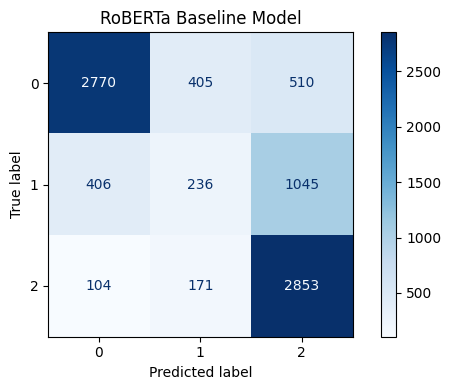

25

In [9]:
print("\n=== BASELINE CONFUSION MATRIX ===")

preds = baseline_trainer.predict(test_dataset)
y_true = preds.label_ids
y_pred = preds.predictions.argmax(-1)

cm = confusion_matrix(y_true, y_pred)
class_names = list(sentiment_to_label.keys())

fig, ax = plt.subplots(figsize=(6, 4))
ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names).plot(cmap="Blues", ax=ax)
ax.set_title("RoBERTa Baseline Model")
plt.tight_layout()
plt.show()

del baseline_model, baseline_trainer
torch.cuda.empty_cache()
gc.collect()

### Fine-tuning BERT

In [10]:
print("=== FINE-TUNING RoBERTa ===")

if torch.cuda.is_available():
    torch.cuda.reset_peak_memory_stats()

start_time = time.time()

config = AutoConfig.from_pretrained(
    base_model_name,
    num_labels=3,
    hidden_dropout_prob=0.4,
    attention_probs_dropout_prob=0.3,
    classifier_dropout=0.4
)

model_base = AutoModelForSequenceClassification.from_pretrained(
    base_model_name,
    config=config
)

total_params_before = sum(p.numel() for p in model_base.parameters())
trainable_params_before = sum(p.numel() for p in model_base.parameters() if p.requires_grad)

training_args = TrainingArguments(
    output_dir="./results",
    num_train_epochs=4,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=1.5e-5,
    weight_decay=0.15,
    warmup_ratio=0.1,
    load_best_model_at_end=True,
    metric_for_best_model="eval_F1 Score",
    greater_is_better=True,
    logging_strategy="epoch",
    report_to="none",
    fp16=True,
    gradient_accumulation_steps=1,
    save_total_limit=2,
    max_grad_norm=1.0,
    lr_scheduler_type="cosine",
    seed=42,
    dataloader_pin_memory=False,
)

trainer_base = Trainer(
    model=model_base,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=2)],
)

trainer_base.train()
training_time = time.time() - start_time
gpu_memory = get_gpu_memory()

finetuned_metrics = trainer_base.evaluate(test_dataset)

results["finetuned_roberta"] = {
    **finetuned_metrics,
    "training_time": training_time,
    "total_parameters": total_params_before,
    "trainable_parameters": trainable_params_before,
    "gpu_memory_gb": gpu_memory
}

=== FINE-TUNING RoBERTa ===


/home/arafatmdeasin/usman/.ve_torch/lib/python3.10/site-packages/huggingface_hub/file_download.py:945: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at roberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/home/arafatmdeasin/usman/.ve_torch/lib/python3.10/site-packages/accelerate/accelerator.py:477: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  self.scaler = torch.cuda.amp.GradScaler(**kwargs)


Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1 score,Similarity score,Confidence score
1,0.692900,0.508921,80.741176,75.959985,74.422613,74.824986,83.979561,89.186478
2,0.518600,0.466123,82.188235,77.931639,77.472611,77.648224,85.413631,88.754425
3,0.468900,0.489846,82.247059,78.233085,78.484692,78.337520,85.241181,90.338783
4,0.445800,0.496026,82.858824,78.757542,78.475219,78.580967,85.520584,91.035599


### Fine-tuned Confusion Matrices


=== FINE-TUNED CONFUSION MATRIX ===


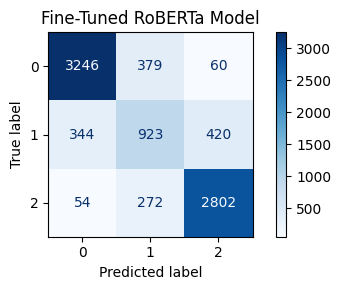

In [11]:
print("\n=== FINE-TUNED CONFUSION MATRIX ===")

preds = trainer_base.predict(test_dataset)
y_true = preds.label_ids
y_pred = preds.predictions.argmax(-1)

cm = confusion_matrix(y_true, y_pred)

fig, ax = plt.subplots(figsize=(5, 3))
ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[0, 1, 2]).plot(cmap="Blues", ax=ax)
ax.set_title("Fine-Tuned RoBERTa Model")
plt.tight_layout()
plt.show()

### Fine-tuned Training & Validation Loss

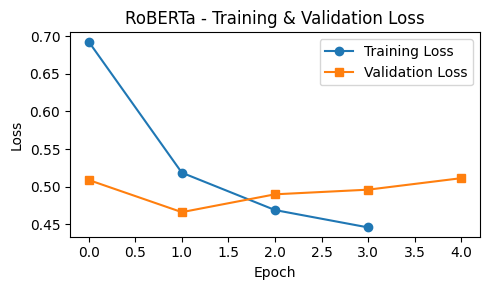

In [12]:
fig, ax = plt.subplots(figsize=(5, 3))

train_loss = [log['loss'] for log in trainer_base.state.log_history if 'loss' in log and 'eval_loss' not in log]
eval_loss = [log['eval_loss'] for log in trainer_base.state.log_history if 'eval_loss' in log]

ax.plot(train_loss, label='Training Loss', marker="o")
ax.plot(eval_loss, label='Validation Loss', marker="s")
ax.set_title('RoBERTa - Training & Validation Loss')
ax.set_xlabel('Epoch')
ax.set_ylabel('Loss')
ax.legend()
ax.grid(False)

plt.tight_layout()
plt.show()

In [13]:
import gc
import torch

for var_name in ["model_base", "trainer_base"]:
    if var_name in globals():
        del globals()[var_name]

torch.cuda.empty_cache()
gc.collect()


16310

### Adapter (LoRA) BERT

In [14]:
print("=== ADAPTER (LoRA) RoBERTa OPTIMIZED ===")

if torch.cuda.is_available():
    torch.cuda.reset_peak_memory_stats()

start_time = time.time()

adapter_model = AutoModelForSequenceClassification.from_pretrained(
    base_model_name,
    num_labels=3
)

peft_config = LoraConfig(
    task_type=TaskType.SEQ_CLS,
    r=4,
    lora_alpha=8,
    lora_dropout=0.1,
    target_modules=["query", "value"],
    bias="none"
)

adapter_model = get_peft_model(adapter_model, peft_config)
adapter_model.print_trainable_parameters()

adapter_args = TrainingArguments(
    output_dir="./results-adapter",
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=3e-4,
    per_device_train_batch_size=32,
    per_device_eval_batch_size=64,
    num_train_epochs=3,
    weight_decay=0.01,
    warmup_ratio=0.05,
    logging_dir="./logs-adapter",
    logging_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="eval_F1 Score",
    greater_is_better=True,
    report_to="none",
    seed=42,
    fp16=True,
    gradient_accumulation_steps=2,
    max_grad_norm=1.0,
    logging_steps=50,
    save_total_limit=1,
    lr_scheduler_type="linear",
    dataloader_pin_memory=False,
    remove_unused_columns=True
)

trainer_adapter = Trainer(
    model=adapter_model,
    args=adapter_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=2)]
)

trainer_adapter.train()
training_time_lora = time.time() - start_time
gpu_memory_lora = get_gpu_memory()

adapter_metrics = trainer_adapter.evaluate(test_dataset)

results['adapter_roberta'] = {
    **adapter_metrics,
    'training_time': training_time_lora,
    'total_parameters': sum(p.numel() for p in adapter_model.parameters()),
    'trainable_parameters': sum(p.numel() for p in adapter_model.parameters() if p.requires_grad),
    'gpu_memory_gb': gpu_memory_lora
}

=== ADAPTER (LoRA) RoBERTa OPTIMIZED ===


Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at roberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/home/arafatmdeasin/usman/.ve_torch/lib/python3.10/site-packages/accelerate/accelerator.py:477: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  self.scaler = torch.cuda.amp.GradScaler(**kwargs)


trainable params: 740,355 || all params: 125,388,294 || trainable%: 0.5904


Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1 score,Similarity score,Confidence score
0,0.508800,0.416637,82.835294,78.701516,76.675656,77.141570,86.165440,85.214531
2,0.394000,0.398426,84.011765,80.227010,78.857761,79.307585,86.890714,86.763855


/home/arafatmdeasin/usman/.ve_torch/lib/python3.10/site-packages/huggingface_hub/file_download.py:945: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
/home/arafatmdeasin/usman/.ve_torch/lib/python3.10/site-packages/huggingface_hub/file_download.py:945: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
/home/arafatmdeasin/usman/.ve_torch/lib/python3.10/site-packages/huggingface_hub/file_download.py:945: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


In [15]:
print(f"Predictions: {np.unique(y_pred)}")


Predictions: [0 1 2]


### Adapter Confusion Matrices


=== ADAPTER CONFUSION MATRIX ===


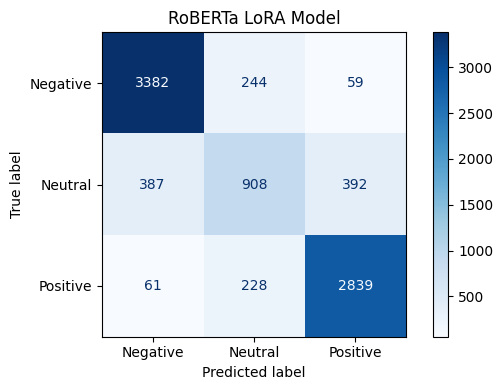

In [16]:
print("\n=== ADAPTER CONFUSION MATRIX ===")

preds = trainer_adapter.predict(test_dataset)
y_true, y_pred = preds.label_ids, preds.predictions.argmax(-1)

cm = confusion_matrix(y_true, y_pred)

fig, ax = plt.subplots(figsize=(6, 4))
ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Negative", "Neutral", "Positive"]).plot(cmap="Blues", ax=ax)
ax.set_title("RoBERTa LoRA Model")
plt.tight_layout()
plt.show()

### Adapter Training & Validation Loss

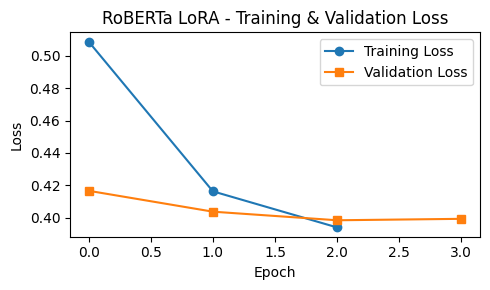

In [17]:
fig, ax = plt.subplots(figsize=(5, 3))

train_loss = [log['loss'] for log in trainer_adapter.state.log_history if 'loss' in log and 'eval_loss' not in log]
eval_loss = [log['eval_loss'] for log in trainer_adapter.state.log_history if 'eval_loss' in log]

ax.plot(train_loss, label='Training Loss', marker="o")
ax.plot(eval_loss, label='Validation Loss', marker="s")
ax.set_title('RoBERTa LoRA - Training & Validation Loss')
ax.set_xlabel('Epoch')
ax.set_ylabel('Loss')
ax.legend()
ax.grid(False)

plt.tight_layout()
plt.show()

### Comprehensive Comparison Table

In [18]:
print("\n" + "="*80)
print("COMPREHENSIVE MODEL COMPARISON")
print("="*80)

comparison_data = []

models = [
    ('Baseline RoBERTa', 'baseline_roberta'),
    ('Fine-Tuned RoBERTa', 'finetuned_roberta'),
    ('Adapter RoBERTa', 'adapter_roberta')
]

for model_name, model_key in models:
    if model_key in results:
        metrics = results[model_key]
        row = {
            'Model': model_name,
            'Accuracy': metrics.get('eval_Accuracy', 0),
            'Precision': metrics.get('eval_Precision', 0),
            'Recall': metrics.get('eval_Recall', 0),
            'F1 Score': metrics.get('eval_F1 Score', 0),
            'Similarity': metrics.get('eval_Similarity Score', 0),
            'Confidence': metrics.get('eval_Confidence Score', 0),
            'Training Time (s)': metrics.get('training_time', 'N/A'),
            'Trainable Params': metrics.get('trainable_parameters', 'N/A'),
            'GPU Memory (GB)': metrics.get('gpu_memory_gb', 'N/A')
        }
        comparison_data.append(row)

comparison_df = pd.DataFrame(comparison_data)

numeric_columns = ['Accuracy', 'Precision', 'Recall', 'F1 Score', 'Similarity', 'Confidence']
for col in numeric_columns:
    comparison_df[col] = comparison_df[col].apply(lambda x: f"{x:.2f}" if isinstance(x, (int, float)) else x)

print("\nCOMPREHENSIVE COMPARISON TABLE:")
print(comparison_df.to_string(index=False))


COMPREHENSIVE MODEL COMPARISON

COMPREHENSIVE COMPARISON TABLE:
             Model Accuracy Precision Recall F1 Score Similarity Confidence Training Time (s) Trainable Params GPU Memory (GB)
  Baseline RoBERTa    68.93     59.41  60.12    58.05      74.16      80.87               N/A              N/A             N/A
Fine-Tuned RoBERTa    82.01     77.70  77.46    77.54      84.91      90.72       1783.457019        124647939        4.148993
   Adapter RoBERTa    83.87     80.13  78.79    79.23      86.82      86.32        910.148825           740355        4.908302


### Performance Visualization

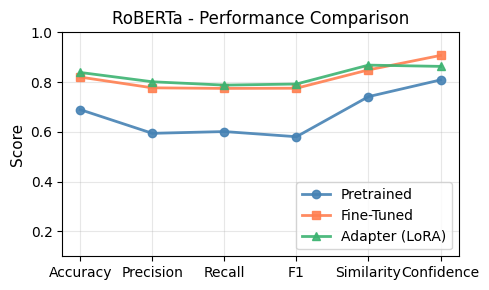

In [19]:
metrics = ["Accuracy", "Precision", "Recall", "F1", "Similarity", "Confidence"]

pretrained_vals = np.array([baseline_metrics[f"eval_{m}"] for m in ["Accuracy", "Precision", "Recall", "F1 Score", "Similarity Score", "Confidence Score"]]) / 100
finetuned_vals = np.array([finetuned_metrics[f"eval_{m}"] for m in ["Accuracy", "Precision", "Recall", "F1 Score", "Similarity Score", "Confidence Score"]]) / 100
adapter_vals = np.array([adapter_metrics[f"eval_{m}"] for m in ["Accuracy", "Precision", "Recall", "F1 Score", "Similarity Score", "Confidence Score"]]) / 100

x = np.arange(len(metrics))

fig, ax = plt.subplots(figsize=(5, 3))

ax.plot(x, pretrained_vals, marker='o', linestyle='-', linewidth=2, alpha=0.9, label="Pretrained", color='steelblue')
ax.plot(x, finetuned_vals, marker='s', linestyle='-', linewidth=2, alpha=0.9, label="Fine-Tuned", color='coral')
ax.plot(x, adapter_vals, marker='^', linestyle='-', linewidth=2, alpha=0.9, label="Adapter (LoRA)", color='mediumseagreen')

ax.set_xticks(x)
ax.set_xticklabels(metrics, fontsize=10)
ax.set_ylabel("Score", fontsize=11)
ax.set_ylim(0.10, 1.00)
ax.set_title("RoBERTa - Performance Comparison", fontsize=12)
ax.grid(True, alpha=0.3)
ax.legend(loc="lower right", fontsize=10)

plt.tight_layout()
plt.show()

### Resource Usage Comparison

In [20]:
roberta_ft = results['finetuned_roberta']
roberta_ad = results['adapter_roberta']

print("\n" + "RoBERTa - RESOURCE USAGE".center(40))
print("-" * 40)
print(f"{'Metric':<20} {'Fine-Tuned':<12} {'Adapter':<12}")
print("-" * 40)
print(f"{'Training Time (s)':<20} {roberta_ft['training_time']:<12.0f} {roberta_ad['training_time']:<12.0f}")
print(f"{'Trainable Params':<20} {roberta_ft['trainable_parameters']:<12,} {roberta_ad['trainable_parameters']:<12,}")
print(f"{'GPU Memory (GB)':<20} {roberta_ft['gpu_memory_gb']:<12.2f} {roberta_ad['gpu_memory_gb']:<12.2f}")
print("-" * 40)


        RoBERTa - RESOURCE USAGE        
----------------------------------------
Metric               Fine-Tuned   Adapter     
----------------------------------------
Training Time (s)    1783         910         
Trainable Params     124,647,939  740,355     
GPU Memory (GB)      4.15         4.91        
----------------------------------------
